In [1]:
!pip install -U pip setuptools wheel
!pip install seqeval

  Using cached seqeval-1.2.2.tar.gz (43 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16251 sha256=14fe353ecb0ba91e5ebacdd8bd0af62b3714d0fabae0b55436cca50e5799e3ad
  Stored in directory: /root/.cache/pip/wheels/14/cf/a7/8f28ef376d707ff10e3922899482a2f23ef3002f8a952f47ac
Successfully built seqeval


In [2]:
import kagglehub
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt


In [3]:
# Download latest version
path = kagglehub.dataset_download("juliangarratt/conll2003-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'conll2003-dataset' dataset.
Path to dataset files: /kaggle/input/conll2003-dataset


In [ ]:
with open("/root/.cache/kagglehub/datasets/juliangarratt/conll2003-dataset/versions/1/conll2003/eng.train","r",encoding="utf-8") as f :
  data_train= f.read()

with open("/root/.cache/kagglehub/datasets/juliangarratt/conll2003-dataset/versions/1/conll2003/eng.testa","r",encoding="utf-8") as f :
  data_validation= f.read()

with open("/root/.cache/kagglehub/datasets/juliangarratt/conll2003-dataset/versions/1/conll2003/eng.testb","r",encoding="utf-8") as f :
  data_test= f.read()


## Exploratory Data Analysis


#### number of sentense

In [ ]:
def analyze_dataset(data):
  sentences = data.strip().split("\n\n")
  num_sentences = len(sentences)
  sentence_lengths=[]

  for sentence in sentences:
    tokens = sentence.split("\n")
    sentence_lengths.append(len(tokens))

  num_tokens = sum(sentence_lengths)
  print("Number of sentences:", num_sentences)
  print("Number of tokens:", num_tokens)
  print("Average sentence length:", np.mean(sentence_lengths))
  print("Minimum sentence length:", np.min(sentence_lengths))
  print("Maximum sentence length:", np.max(sentence_lengths))
  print("-" * 40)


analyze_dataset(data_train)
analyze_dataset(data_validation)
analyze_dataset(data_test)



Number of sentences: 14987
Number of tokens: 204567
Average sentence length: 13.649629679055181
Minimum sentence length: 1
Maximum sentence length: 113
----------------------------------------
Number of sentences: 3466
Number of tokens: 51578
Average sentence length: 14.881130986728216
Minimum sentence length: 1
Maximum sentence length: 109
----------------------------------------
Number of sentences: 3684
Number of tokens: 46666
Average sentence length: 12.667209554831704
Minimum sentence length: 1
Maximum sentence length: 124
----------------------------------------


#### Distribution

In [ ]:
sentences = data_train.strip().split("\n\n")
labels=[]


for sentence in sentences:
  lines = sentence.split("\n")

  for line in lines:
    columns= line.split()

    if len(columns)>=4:
      ner_label = columns[3]
      labels.append(ner_label)
print(labels[:20])


['O', 'B-ORG', 'O', 'B-MISC', 'O', 'O', 'O', 'B-MISC', 'O', 'O', 'B-PER', 'I-PER', 'B-LOC', 'O', 'O', 'B-ORG', 'I-ORG', 'O', 'O', 'O']


In [ ]:
sentences = data_train.strip().split("\n\n")
words=[]

for sentence in sentences:
  lines = sentence.split("\n")

  for line in lines:
    columns= line.split()

    if len(columns)>=4:
      ner_label = columns[0]
      words.append(ner_label)
print(words[:20])


['-DOCSTART-', 'EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.', 'Peter', 'Blackburn', 'BRUSSELS', '1996-08-22', 'The', 'European', 'Commission', 'said', 'on', 'Thursday']


In [ ]:
label_counts = Counter(labels)

print("Labels distributions:")
for label, count in label_counts.items():
    print(f"{label}: {count}")

Labels distributions:
O: 170524
B-ORG: 6321
B-MISC: 3438
B-PER: 6600
I-PER: 4528
B-LOC: 7140
I-ORG: 3704
I-MISC: 1155
I-LOC: 1157


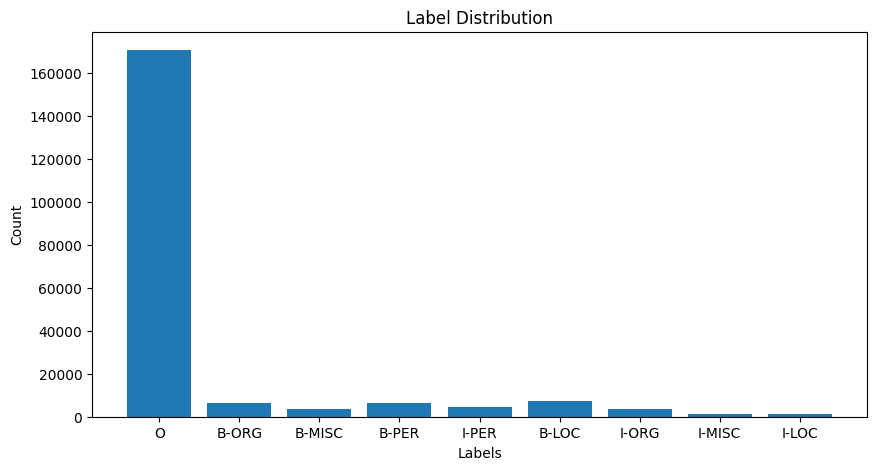

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(label_counts.keys(),label_counts.values())
plt.xlabel("Labels")
plt.ylabel("Count")
plt.title("Label Distribution")
plt.show()


In [ ]:
entity_types=[]

for label in labels:

  if label!= "O":
    entity_type = label.split("-")[1]
    entity_types.append(entity_type)

entity_counts = Counter(entity_types)
print("entity counts")
for entity,count in entity_counts.items():
  print(f"{entity}:{count}")


entity counts
ORG:10025
MISC:4593
PER:11128
LOC:8297


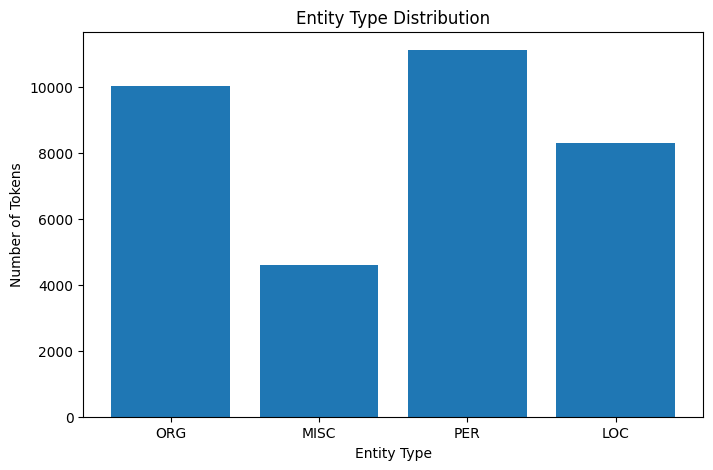

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(entity_counts.keys(), entity_counts.values())

plt.xlabel("Entity Type")
plt.ylabel("Number of Tokens")
plt.title("Entity Type Distribution")

plt.show()

In [ ]:
entities = []

for sentence in sentences:

    current_entity = []
    current_type = None

    for line in sentence.split("\n"):

        columns = line.split()

        if len(columns) < 4:
            continue

        word = columns[0]
        label = columns[3]

        if label.startswith("B-"):

            # Save previous entity
            if current_entity:
                entities.append(
                    (" ".join(current_entity), current_type)
                )

            current_entity = [word]
            current_type = label[2:]

        elif label.startswith("I-"):

            current_entity.append(word)

        else:  # O

            if current_entity:
                entities.append(
                    (" ".join(current_entity), current_type)
                )

                current_entity = []
                current_type = None

    # Save entity at end of sentence
    if current_entity:
        entities.append(
            (" ".join(current_entity), current_type)
        )

print(entities[:20])

[('EU', 'ORG'), ('German', 'MISC'), ('British', 'MISC'), ('Peter Blackburn', 'PER'), ('BRUSSELS', 'LOC'), ('European Commission', 'ORG'), ('German', 'MISC'), ('British', 'MISC'), ('Germany', 'LOC'), ('European Union', 'ORG'), ('Werner Zwingmann', 'PER'), ('Britain', 'LOC'), ('Commission', 'ORG'), ('Nikolaus van der Pas', 'PER'), ('European Union', 'ORG'), ('EU', 'ORG'), ('Franz Fischler', 'PER'), ('Fischler', 'PER'), ('EU-wide', 'MISC'), ('Britain', 'LOC')]


In [ ]:
entity_frequency = Counter(
    entity[0] for entity in entities
)

print(entity_frequency.most_common(10))


[('U.S.', 303), ('Germany', 141), ('Britain', 133), ('Australia', 130), ('England', 123), ('France', 122), ('Spain', 110), ('Italy', 98), ('NEW YORK', 95), ('LONDON', 93)]


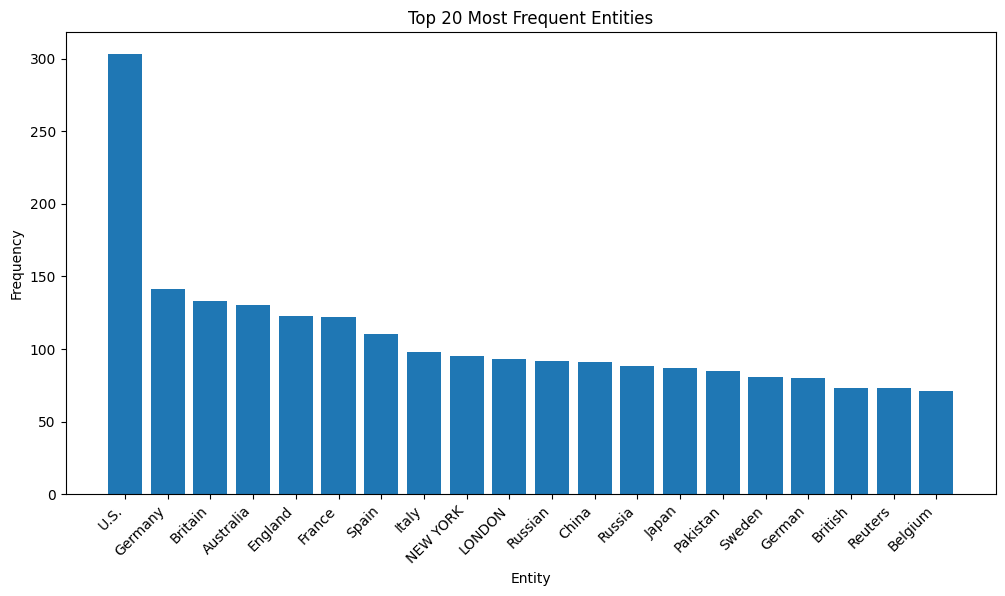

In [ ]:
top_entities = entity_frequency.most_common(20)

names = [x[0] for x in top_entities]
counts = [x[1] for x in top_entities]

plt.figure(figsize=(12, 6))

plt.bar(names, counts)

plt.xlabel("Entity")
plt.ylabel("Frequency")
plt.title("Top 20 Most Frequent Entities")

plt.xticks(rotation=45, ha="right")

plt.show()

In [ ]:
entity_lengths = []

for entity, entity_type in entities:

    length = len(entity.split())

    entity_lengths.append(length)

print(entity_lengths[:20])

[1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 2, 1, 1, 4, 2, 1, 2, 1, 1, 1]


In [ ]:
print("Average entity length:", np.mean(entity_lengths))
print("Minimum entity length:", np.min(entity_lengths))
print("Maximum entity length:", np.max(entity_lengths))

Average entity length: 1.448699944678497
Minimum entity length: 1
Maximum entity length: 10


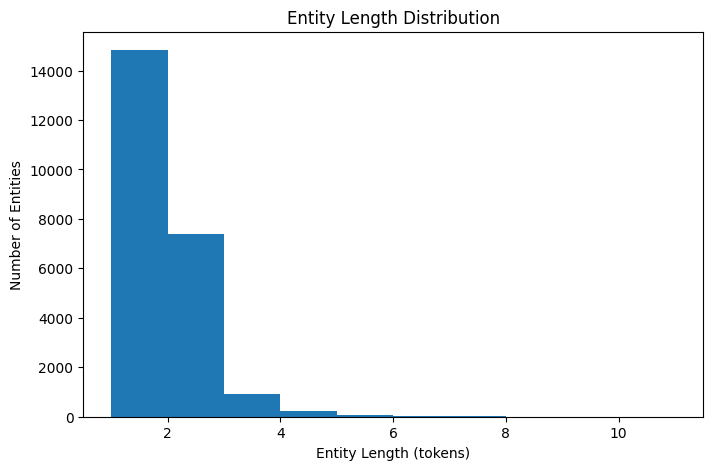

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(entity_lengths, bins=range(1, max(entity_lengths) + 2))

plt.xlabel("Entity Length (tokens)")
plt.ylabel("Number of Entities")
plt.title("Entity Length Distribution")

plt.show()

#### Linguistic Analysis


In [ ]:
words = []
for sentence in sentences:
    for line in sentence.split("\n"):

        columns = line.split()

        if len(columns) >= 4:
            word = columns[0]
            words.append(word.lower())

word_frequency = Counter(words)

print(word_frequency.most_common(20))

[('the', 8390), ('.', 7374), (',', 7290), ('of', 3815), ('in', 3621), ('to', 3424), ('a', 3199), ('and', 2872), ('(', 2861), (')', 2861), ('"', 2178), ('on', 2092), ('said', 1849), ("'s", 1566), ('for', 1465), ('1', 1421), ('-', 1243), ('at', 1146), ('was', 1095), ('2', 973)]


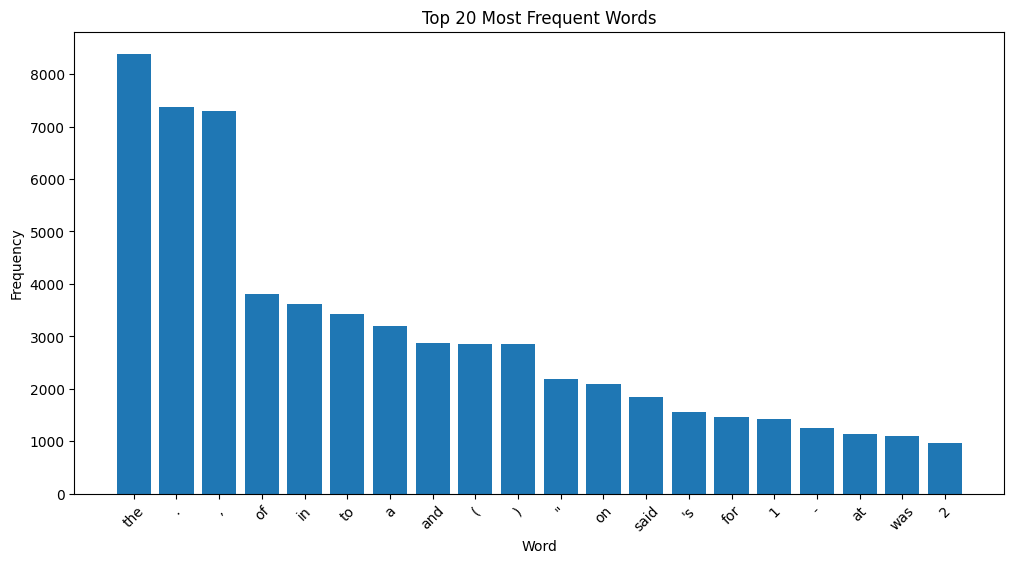

In [ ]:
import matplotlib.pyplot as plt

top_words = word_frequency.most_common(20)

words_names = [x[0] for x in top_words]
words_counts = [x[1] for x in top_words]

plt.figure(figsize=(12, 6))

plt.bar(words_names, words_counts)

plt.xlabel("Word")
plt.ylabel("Frequency")
plt.title("Top 20 Most Frequent Words")

plt.xticks(rotation=45)

plt.show()

#### POS Tag Distribution

In [ ]:
pos_tags = []

for sentence in sentences:
    for line in sentence.split("\n"):

        columns = line.split()

        if len(columns) >= 4:
            pos = columns[1]
            pos_tags.append(pos)

pos_frequency = Counter(pos_tags)

print(pos_frequency.most_common(10))

[('NNP', 34392), ('NN', 23899), ('CD', 19704), ('IN', 19064), ('DT', 13453), ('JJ', 11831), ('NNS', 9903), ('VBD', 8293), ('.', 7389), (',', 7291)]


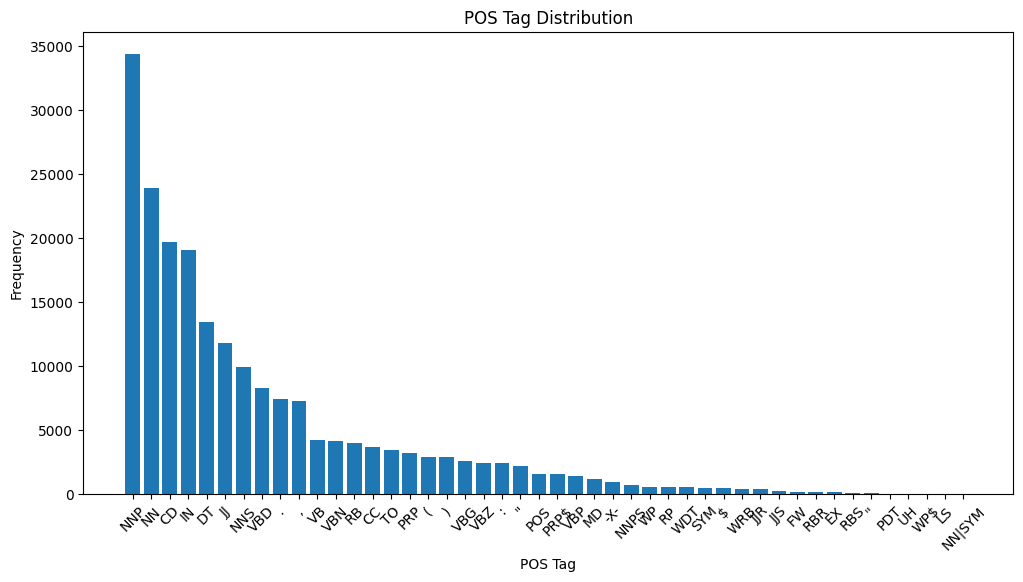

In [ ]:
top_pos = pos_frequency.most_common()

pos_names = [x[0] for x in top_pos]
pos_counts = [x[1] for x in top_pos]

plt.figure(figsize=(12, 6))

plt.bar(pos_names, pos_counts)

plt.xlabel("POS Tag")
plt.ylabel("Frequency")
plt.title("POS Tag Distribution")

plt.xticks(rotation=45)

plt.show()

#### Data Quality

In [ ]:
empty_sentences = 0

for sentence in sentences:

    if len(sentence.strip()) == 0:
        empty_sentences += 1

print("Empty sentences:", empty_sentences)

Empty sentences: 0


#### Missing values

In [ ]:
invalid_lines = []

for sentence in sentences:

    for line in sentence.split("\n"):

        columns = line.split()

        if len(columns) < 4:
            invalid_lines.append(line)

print("Invalid lines:", len(invalid_lines))

Invalid lines: 0


#### Duplicates

In [ ]:
from collections import Counter

sentence_strings = [
    sentence.strip()
    for sentence in sentences
]

counts = Counter(sentence_strings)

duplicates = {
    sentence: count
    for sentence, count in counts.items()
    if count > 1
}

print("Number of duplicated sentences:", len(duplicates))

for sentence, count in list(duplicates.items())[:5]:
    print("Appears:", count, "times")
    print(sentence)
    print("-" * 50)

Number of duplicated sentences: 721
Appears: 946 times
-DOCSTART- -X- -X- O
--------------------------------------------------
Appears: 2 times
BRUSSELS NNP B-NP B-LOC
1996-08-22 CD I-NP O
--------------------------------------------------
Appears: 3 times
. . O O
--------------------------------------------------
Appears: 2 times
It PRP B-NP O
brought VBD B-VP O
in IN B-PP O
4,275 CD B-NP O
tonnes NNS I-NP O
of IN B-PP O
British JJ B-NP B-MISC
mutton NN I-NP O
, , O O
some DT B-NP O
10 CD I-NP O
percent NN I-NP O
of IN B-PP O
overall JJ B-NP O
imports NNS I-NP O
. . O O
--------------------------------------------------
Appears: 12 times
LONDON NNP B-NP B-LOC
1996-08-22 CD I-NP O
--------------------------------------------------


#### BIO consistency

In [ ]:
invalid_bio = []

for sentence in sentences:

    previous_label = "O"

    for line in sentence.split("\n"):

        columns = line.split()

        if len(columns) < 4:
            continue

        word = columns[0]
        label = columns[3]

        if label.startswith("I-"):

            entity_type = label[2:]

            # Previous token must be B-type or I-same-type
            if previous_label not in [
                "B-" + entity_type,
                "I-" + entity_type
            ]:
                invalid_bio.append((word, label))

        previous_label = label

print("Invalid BIO labels:", len(invalid_bio))

Invalid BIO labels: 0


## Tokenization

In [4]:
def load_conll(path):

    sentences = []

    with open(path, "r", encoding="utf-8") as f:

        tokens = []
        labels = []

        for line in f:

            line = line.strip()
            if line.startswith("-DOCSTART-"):
              continue
            # Empty line = end of sentence
            if not line:

                if tokens:
                    sentences.append({
                        "tokens": tokens,
                        "labels": labels
                    })

                tokens = []
                labels = []

            else:

                columns = line.split()

                if len(columns) >= 4:
                    word = columns[0]
                    ner_label = columns[3]

                    tokens.append(word)
                    labels.append(ner_label)

        if tokens:
            sentences.append({
                "tokens": tokens,
                "labels": labels
            })

    return sentences

In [5]:
data_train=load_conll("/kaggle/input/conll2003-dataset/conll2003/eng.train")
data_validation=load_conll("/kaggle/input/conll2003-dataset/conll2003/eng.testa")
data_test=load_conll("/kaggle/input/conll2003-dataset/conll2003/eng.testb")

In [6]:
print(data_train[:3])

[{'tokens': ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.'], 'labels': ['B-ORG', 'O', 'B-MISC', 'O', 'O', 'O', 'B-MISC', 'O', 'O']}, {'tokens': ['Peter', 'Blackburn'], 'labels': ['B-PER', 'I-PER']}, {'tokens': ['BRUSSELS', '1996-08-22'], 'labels': ['B-LOC', 'O']}]


In [7]:
from datasets import Dataset

data_train = Dataset.from_list(data_train)
data_validation = Dataset.from_list(data_validation)
data_test = Dataset.from_list(data_test)

In [8]:
unique_val=set()

for label in data_train["labels"]:
  unique_val.update(label)
print(unique_val)

{'B-PER', 'I-MISC', 'I-PER', 'O', 'I-ORG', 'I-LOC', 'B-ORG', 'B-MISC', 'B-LOC'}


In [9]:
label2id={
    label: i
    for i, label in enumerate(sorted(unique_val))

}
print(label2id)

{'B-LOC': 0, 'B-MISC': 1, 'B-ORG': 2, 'B-PER': 3, 'I-LOC': 4, 'I-MISC': 5, 'I-ORG': 6, 'I-PER': 7, 'O': 8}


In [10]:
id2label = {
    i: label
    for label, i in label2id.items()
}

print(id2label)

{0: 'B-LOC', 1: 'B-MISC', 2: 'B-ORG', 3: 'B-PER', 4: 'I-LOC', 5: 'I-MISC', 6: 'I-ORG', 7: 'I-PER', 8: 'O'}


In [32]:
import transformers
from transformers import AutoTokenizer
model_checkpoint = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
#to search about
assert isinstance(tokenizer, transformers.PreTrainedTokenizerFast)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [33]:
def tokenize_and_align_labels(examples):

    # 1. Tokenization
    tokenized_inputs = tokenizer(
        examples["tokens"],
        is_split_into_words=True,
        truncation=True
    )

    all_labels = []

    # 2. Process each sentence
    for i, sentence_labels in enumerate(examples["labels"]):

        # Get the original word index for each token
        word_ids = tokenized_inputs.word_ids(batch_index=i)

        label_ids = []
        previous_word_id = None

        # 3. Align labels with tokens
        for word_id in word_ids:

            # [CLS], [SEP], padding...
            if word_id is None:
                label_ids.append(-100)

            # First subword of a word
            elif word_id != previous_word_id:
                label_ids.append(
                    label2id[sentence_labels[word_id]]
                )

            # Other subwords of the same word
            else:
                label_ids.append(-100)

            previous_word_id = word_id

        all_labels.append(label_ids)

    # 4. Add aligned labels to tokenizer output
    tokenized_inputs["labels"] = all_labels

    return tokenized_inputs

In [34]:
tokenized_train = data_train.map(
    tokenize_and_align_labels,
    batched=True
)

Map:   0%|          | 0/14041 [00:00<?, ? examples/s]

In [35]:
tokenized_validation = data_validation.map(
    tokenize_and_align_labels,
    batched=True
)

Map:   0%|          | 0/3250 [00:00<?, ? examples/s]

In [36]:
tokenized_test = data_test.map(
    tokenize_and_align_labels,
    batched=True
)

Map:   0%|          | 0/3453 [00:00<?, ? examples/s]

In [16]:
print(tokenized_train)

Dataset({
    features: ['tokens', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 14041
})


In [ ]:
print(tokenized_train["tokens"][:2])
print(tokenized_train["labels"][:2])
print(tokenized_train["input_ids"][:2])
print(tokenized_train["attention_mask"][:2])

[['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.'], ['Peter', 'Blackburn']]
[[-100, 2, 8, 1, 8, 8, 8, 1, 8, 8, -100], [-100, 3, 7, -100]]
[[101, 7327, 19164, 2446, 2655, 2000, 17757, 2329, 12559, 1012, 102], [101, 2848, 13934, 102]]
[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1]]


## Training model

In [37]:
from transformers import AutoModelForTokenClassification

model = AutoModelForTokenClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly

In [38]:
print(model.num_labels)

9


In [39]:
from transformers import DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(
    tokenizer=tokenizer
)

In [40]:
import numpy as np
from seqeval.metrics import precision_score, recall_score, f1_score, accuracy_score


def compute_metrics(eval_prediction):

    predictions, labels = eval_prediction

    # Get predicted label IDs
    predictions = np.argmax(predictions, axis=2)

    true_labels = []
    true_predictions = []

    for prediction, label in zip(predictions, labels):

        sentence_labels = []
        sentence_predictions = []

        for pred_id, label_id in zip(prediction, label):

            # Ignore special tokens / subword tokens
            if label_id == -100:
                continue

            sentence_labels.append(id2label[label_id])
            sentence_predictions.append(id2label[pred_id])

        true_labels.append(sentence_labels)
        true_predictions.append(sentence_predictions)

    return {
        "precision": precision_score(true_labels, true_predictions),
        "recall": recall_score(true_labels, true_predictions),
        "f1": f1_score(true_labels, true_predictions),
        "accuracy": accuracy_score(true_labels, true_predictions)
    }

In [41]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir = "./ner_model",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
)


In [42]:
from transformers import Trainer,EarlyStoppingCallback

trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=tokenized_train,
    eval_dataset=tokenized_validation,

    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],


)

In [43]:
import torch

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Model device:", model.device)

GPU available: True
GPU: Tesla T4
Model device: cuda:0


In [44]:
trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.175071,0.049464,0.919781,0.932009,0.925855,0.986177
2,0.036317,0.048666,0.928985,0.944463,0.936660,0.987384
3,0.019801,0.049528,0.936181,0.947997,0.942052,0.988279


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=2634, training_loss=0.06033105658326261, metrics={'train_runtime': 564.2539, 'train_samples_per_second': 74.653, 'train_steps_per_second': 4.668, 'total_flos': 1020143109346326.0, 'train_loss': 0.06033105658326261, 'epoch': 3.0})

In [45]:
results = trainer.evaluate()

print(results)

Training Loss,Validation Loss,Epoch,Precision,Recall,F1,Accuracy
0.019801,0.048672,3,0.928997,0.944631,0.936749,0.987423


{'eval_loss': 0.04867178201675415, 'eval_precision': 0.9289970208540218, 'eval_recall': 0.9446314372265231, 'eval_f1': 0.9367489986648866, 'eval_accuracy': 0.987422608153888}


In [46]:
predictions = trainer.predict(tokenized_test)

import numpy as np

logits = predictions.predictions
true_labels = predictions.label_ids

pred_ids = np.argmax(logits, axis=-1)

In [47]:
true_labels_clean = []
pred_labels_clean = []

for pred_sentence, true_sentence in zip(pred_ids, true_labels):

    true_sentence_labels = []
    pred_sentence_labels = []

    for pred_id, true_id in zip(pred_sentence, true_sentence):

        if true_id == -100:
            continue

        true_sentence_labels.append(id2label[true_id])
        pred_sentence_labels.append(id2label[pred_id])

    true_labels_clean.append(true_sentence_labels)
    pred_labels_clean.append(pred_sentence_labels)

In [48]:
from seqeval.metrics import (
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

precision = precision_score(
    true_labels_clean,
    pred_labels_clean
)

recall = recall_score(
    true_labels_clean,
    pred_labels_clean
)

f1 = f1_score(
    true_labels_clean,
    pred_labels_clean
)

print("Test Precision:", precision)
print("Test Recall:", recall)
print("Test F1:", f1)

print("\nTest Classification Report:")
print(classification_report(
    true_labels_clean,
    pred_labels_clean
))

Test Precision: 0.8896587562792309
Test Recall: 0.9093484419263456
Test F1: 0.8993958497504596

Test Classification Report:
              precision    recall  f1-score   support

         LOC       0.90      0.94      0.92      1668
        MISC       0.75      0.83      0.79       702
         ORG       0.86      0.87      0.87      1661
         PER       0.98      0.96      0.97      1617

   micro avg       0.89      0.91      0.90      5648
   macro avg       0.87      0.90      0.88      5648
weighted avg       0.89      0.91      0.90      5648



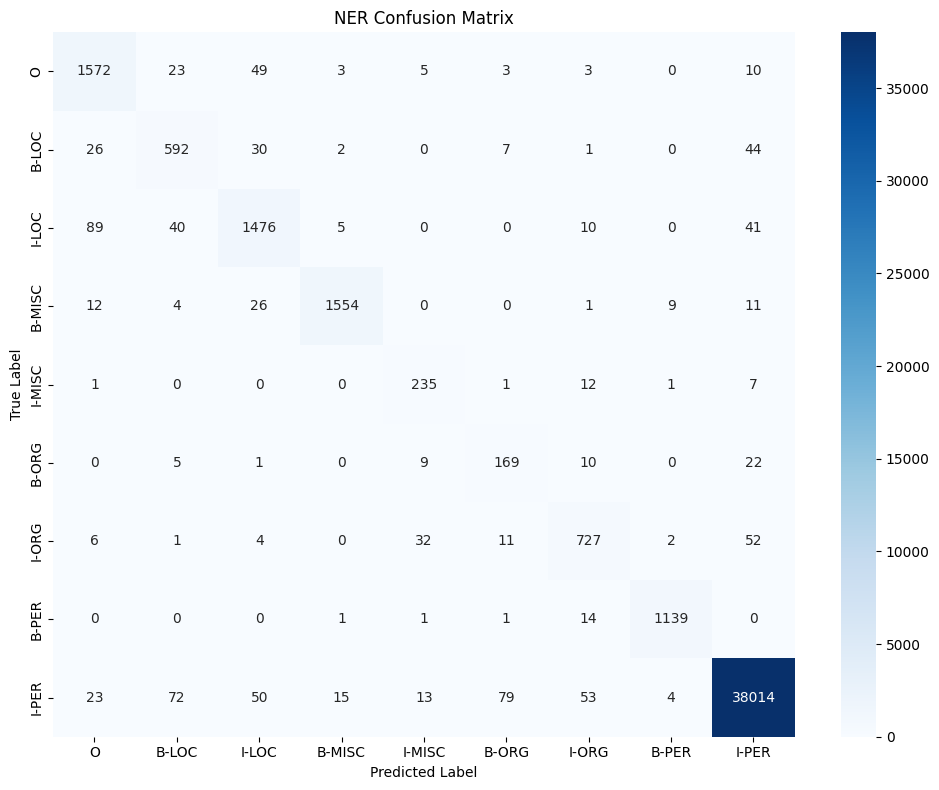

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# Get predictions
predictions = trainer.predict(tokenized_test)

logits = predictions.predictions
labels = predictions.label_ids

# Convert logits to predicted class IDs
pred_ids = np.argmax(logits, axis=-1)


# Remove -100 tokens
true_labels = []
pred_labels = []

for true_seq, pred_seq in zip(labels, pred_ids):

    for true_label, pred_label in zip(true_seq, pred_seq):

        if true_label != -100:
            true_labels.append(true_label)
            pred_labels.append(pred_label)


# Label names
label_names = [
    "O",
    "B-LOC",
    "I-LOC",
    "B-MISC",
    "I-MISC",
    "B-ORG",
    "I-ORG",
    "B-PER",
    "I-PER"
]


# Confusion matrix
cm = confusion_matrix(
    true_labels,
    pred_labels,
    labels=range(len(label_names))
)


# Plot
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("NER Confusion Matrix")

plt.tight_layout()
plt.show()

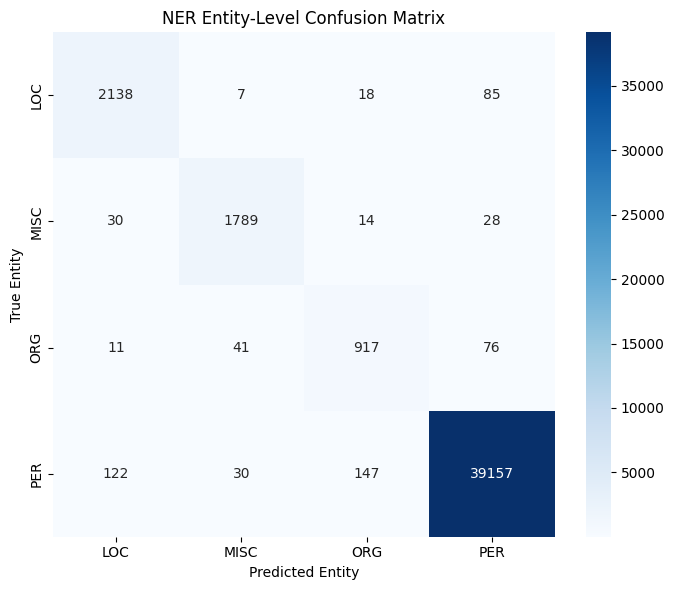

In [50]:
def get_entity_type(label):
    if label == "O":
        return "O"

    return label.split("-")[-1]

true_entity_labels = [
    get_entity_type(label_names[i])
    for i in true_labels
]

pred_entity_labels = [
    get_entity_type(label_names[i])
    for i in pred_labels
]

entity_labels = ["LOC", "MISC", "ORG", "PER"]

cm = confusion_matrix(
    true_entity_labels,
    pred_entity_labels,
    labels=entity_labels
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=entity_labels,
    yticklabels=entity_labels
)

plt.xlabel("Predicted Entity")
plt.ylabel("True Entity")
plt.title("NER Entity-Level Confusion Matrix")

plt.tight_layout()
plt.show()